# Why does the data-preparation appendix need a stratified split at all?

This notebook reproduces `Plots/Fig_A1.pdf` (`fig:number_of_snapshots`) and
`Plots/Fig_A2.pdf` (`fig:app:XY_delta_avg`), the two figures of App. A, "Snapshot
imbalance across the sweep and data splitting" and "Combining two measurement bases"
(Figs. 7 and 8, App. A 1 and A 2). It also produces `Plots/Fig_A3.pdf`,
which backs that appendix's claim that the results are insensitive to the train/val
splitting strategy; that claim is currently stated in prose only, and `Fig_A3.pdf` is
not included as a captioned figure in the compiled manuscript.

### The question

Experimental snapshots are not acquired uniformly across the sweep: some time points
carry an order of magnitude more shots than others (App. A, "Snapshot imbalance across
the sweep and data splitting", `app:snapshot_imbalance`). A naive random train/val split
can therefore starve a sparse time
point of validation examples, or worse, of training examples entirely, right where the
physics is most interesting. `Fig_A1.pdf` makes that imbalance visible for both
datasets, which is what motivates the stratified (`even_split`) train/val split used
throughout this work, together with the optional per-time-point sample cap
(`samples_per_pt_cap`) and weighted-loss alternative described in the same appendix.
`Fig_A2.pdf` addresses a second, unrelated wrinkle specific to the XY dataset: its $X$-
and $Z$-basis snapshots come from two separate experimental sweeps whose realized
control fields do not quite coincide, which is why the combined $XZ$ dataset uses the
arithmetic mean of the two as its effective tuning parameter.

### What it reads

Unlike the other appendix notebooks, this one calls the data processors
(`IsingDataProcessor`, `XYDataProcessor`, `create_datasets()`) directly rather than
reading a pre-extracted `Plots_data/` or `App_*_data/` summary, so producing `Fig_A1.pdf`
and `Fig_A2.pdf` needs the full raw `datasets/` (or legacy `data/`) experimental
snapshot tree checked out locally, not merely the small tracked appendix data folders
(see the README's "Data and trained runs" section for why this tree ships separately
from the code). `Fig_A3.pdf` is the exception: it reads pre-computed summaries from the tracked
`Plots_data/App_A_data/*.pickle` files and needs no raw data at all.


In [1]:
import os
from pathlib import Path

from tetriscnn import PAPER_MPLSTYLE
from tetriscnn.models import *
from tetriscnn.utils import *
from tetriscnn.datasets import *
from tetriscnn.plots import *
from tetriscnn.dataprocessing import IsingDataProcessor, XYDataProcessor

import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import matplotlib.gridspec as gs

import os
from collections import defaultdict

DEVICE = "cpu"

# Paths below (Plots_data/ in, Plots/ out) are relative to the repository root;
# move there so the notebook runs the same from the root or from notebooks/.
os.chdir(next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()))
Path("Plots/SVG").mkdir(parents=True, exist_ok=True)

## Loading the datasets

`create_datasets()` is the same factory used throughout training (see
`docs/CONFIGURATION.md`, "Dataset selection and splitting"); it is called here once per dataset just to recover
each processor's per-time-point tuning-parameter values. Only the XY branches feed the
rest of this notebook: `XYZ_times`/`XYZ_deltas`, `XYX_times`/`XYX_deltas` and
`XYXZ_times`/`XYXZ_deltas` are what `Fig_A2.pdf` plots below. The Ising dataset, its
loader, and its `delta`/`omega` dictionaries are built here too but never referenced
again in this notebook; they are left in as a ready-made starting point for further
diagnostics rather than removed.


In [2]:
cf = AttrDict() # Describes all the 'knobs' of an experiment
cf.seed = 42
set_seeds(cf.seed)

cf.task = "regression"        # choose between "regression" and "classification"
cf.label_param = "t"      # label parameter for the Paris datasets; 't', 'delta', 'omega' for Ising, 't' for XY, 'beta' for ILGT
cf.normalize_labels = True    # normalize labels to [0, 1] range, only for regression
cf.label_subset_count = None   # number between 0 and 100
cf.filter_t_values = None

cf.data_fraction = 1.0
cf.param_cutoffs = {"delta" : 6, "omega" : 0}         # NB: for XZ, delta = 11 gives divergence
cf.even_split = True
cf.samples_per_pt_cap = None


cf.dataset = "Paris_Ising"  
Ising_dataset, _ = create_datasets(cf)
Ising_loader = DataLoader(Ising_dataset, batch_size=1, shuffle=True) # type: ignore
Ising_deltas = np.array(list( Ising_dataset.processor.delta_dict.values() )) # type: ignore
Ising_omegas = np.array(list( Ising_dataset.processor.omega_dict.values() )) # type: ignore
Ising_times = Ising_dataset.unique_times.cpu().numpy() / 1e3


cf.dataset = "Paris_XY_Z" 
XYZ_dataset, _ = create_datasets(cf)
XYZ_loader = DataLoader(XYZ_dataset, batch_size=1, shuffle=True) # type: ignore
XYZ_deltas = np.array(list( XYZ_dataset.processor.delta_dict_z.values() )) # type: ignore
XYZ_times = XYZ_dataset.unique_times.cpu().numpy() / 1e3


cf.dataset = "Paris_XY_X" 
XYX_dataset, _ = create_datasets(cf)
XYX_loader = DataLoader(XYX_dataset, batch_size=1, shuffle=True) # type: ignore
XYX_deltas = np.array(list( XYX_dataset.processor.delta_dict_x.values() )) # type: ignore
XYX_times = XYX_dataset.unique_times.cpu().numpy() / 1e3

cf.dataset = "Paris_XY_XZ" 
XYXZ_dataset, _ = create_datasets(cf)
XYXZ_loader = DataLoader(XYXZ_dataset, batch_size=1, shuffle=True) # type: ignore
XYXZ_deltas = np.array(list( XYXZ_dataset.processor.delta_dict_combined.values() )) # type: ignore
XYXZ_times = XYXZ_dataset.unique_times.cpu().numpy() / 1e3


[Even Split] Found 28 time points
[Even Split] Samples per time point: min=297, max=1322, median=824.0
[Even Split] After per-time-point 70/30 split: 14613 train, 6282 val samples
times shape: 14613, labels shape: torch.Size([14613])
times shape: 6282, labels shape: torch.Size([6282])
directory:  <repo>/datasets/experimental/XY/6x7_atoms_Z_ferro_video_15MHz_tau0p3_16032022_7_0_defects_0_holes



[Even Split] Found 21 time points
[Even Split] Samples per time point: min=371, max=6539, median=842.0
[Even Split] After per-time-point 70/30 split: 18837 train, 8087 val samples
times shape: 18837, labels shape: torch.Size([18837])
times shape: 8087, labels shape: torch.Size([8087])
directory:  <repo>/datasets/experimental/XY/6x7_atoms_X_ferro_video_15MHz_tau0p3_17032022_0_defects_0_holes



[Even Split] Found 13 time points
[Even Split] Samples per time point: min=792, max=2574, median=1000.0
[Even Split] After per-time-point 70/30 split: 11532 train, 4952 val samples
times shape: 11532, labels shape: torch.Size([11532])
times shape: 4952, labels shape: torch.Size([4952])



[Even Split] Found 13 time points
[Even Split] Samples per time point: min=371, max=2574, median=995.0
[Even Split] After per-time-point 70/30 split: 10124 train, 4347 val samples
times shape: 10124, labels shape: torch.Size([10124])
times shape: 4347, labels shape: torch.Size([4347])


In [3]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.gridspec as gridspec
from tetriscnn.colors import COLORS, colors

plt.style.use(PAPER_MPLSTYLE)

SINGLE_WIDTH = 3.4
DOUBLE_WIDTH = 6.80914
golden_ratio = (1 + np.sqrt(5)) / 2

## Fig_A1: how unevenly are snapshots distributed across the sweep?

`count_snapshots_per_timepoint` walks a processor's raw `samples` list and tallies how
many snapshots land at each recorded time value, independently of any train/val split.
The cell below runs this for the Ising processor and, separately, for the XY processor
built at each of its three bases ($Z$, $X$, $XZ$): the $XZ$ basis pairs one $X$- and one
$Z$-basis snapshot per example, so it has strictly fewer usable snapshots at a given
time than either basis alone, and only at the time points the two source sweeps share.

The resulting figure is two stacked panels: (a) the Ising sweep as a single histogram,
(b) the XY sweep with all three bases overlaid, the $Z$-basis bars drawn full width and
the $X$/$XZ$ bars layered on top only at the time points they actually reach. The red
dashed line in each panel marks the minimum snapshot count anywhere in that sweep
(printed below as part of the cell's output, and quoted in the appendix as $297$ for
Ising and $371$ for XY), the number a global, unstratified split would effectively be
limited by at that time point.


Loading Ising dataset...


Ising: 28 time points, 20895 total snapshots
  Min snapshots: 297, Max: 1322, Mean: 746.2

Loading XY dataset (Z basis)...
directory:  <repo>/datasets/experimental/XY/6x7_atoms_Z_ferro_video_15MHz_tau0p3_16032022_7_0_defects_0_holes


XY (Z): 21 time points, 26924 total snapshots
  Min snapshots: 371, Max: 6539, Mean: 1282.1

Loading XY dataset (XZ basis)...


XY (XZ): 13 time points, 14471 total snapshots
  Min snapshots: 371, Max: 2574, Mean: 1113.2

Loading XY dataset (X basis)...
directory:  <repo>/datasets/experimental/XY/6x7_atoms_X_ferro_video_15MHz_tau0p3_17032022_0_defects_0_holes


XY (X): 13 time points, 16484 total snapshots
  Min snapshots: 792, Max: 2574, Mean: 1268.0



Plot saved to: Plots/Fig_A1.pdf


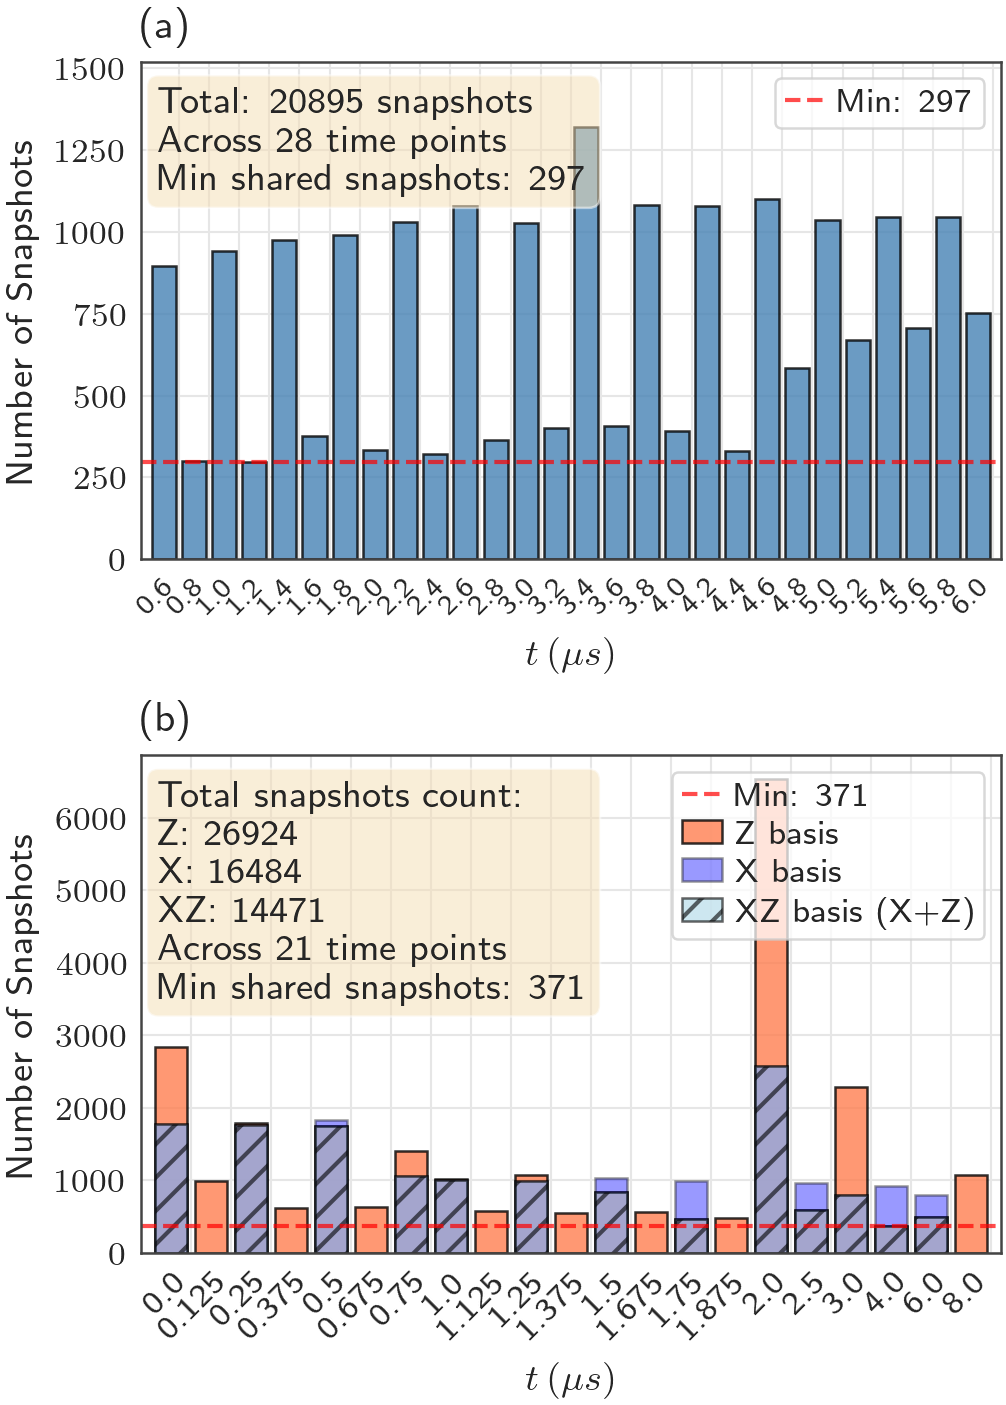

In [4]:
def count_snapshots_per_timepoint(processor):
    """
    Count the number of snapshots for each time point in a processor.

    Args:
        processor: Data processor object (Ising_DataProcessor or XY_DataProcessor)

    Returns:
        dict: Dictionary mapping time values to snapshot counts
    """
    time_counts = defaultdict(int)

    for _, label in processor.samples:
        # Extract time value (label is a tensor)
        time_val = label.item() if label.numel() == 1 else tuple(label.tolist())
        time_counts[time_val] += 1

    # Sort by time
    sorted_times = sorted(time_counts.keys())
    counts = [time_counts[t] for t in sorted_times]

    return sorted_times, counts



"""Create the two-subplot histogram showing snapshot distribution."""

# Create figure with two vertically stacked subplots
fig = plt.figure(figsize=(SINGLE_WIDTH, 2.25 * SINGLE_WIDTH / golden_ratio))

gs = gridspec.GridSpec(2, 1, figure=fig,
                       )

ax_ising = fig.add_subplot(gs[0])
ax_xy = fig.add_subplot(gs[1])

# === Ising Model (top plot) ===
print("Loading Ising dataset...")
ising_processor = IsingDataProcessor(
    data_format='-11',
    discrete_labels=False,
    label_param='t'  # Use time as label to get all samples
)

ising_times, ising_counts = count_snapshots_per_timepoint(ising_processor)

print(f"Ising: {len(ising_times)} time points, {sum(ising_counts)} total snapshots")
print(f"  Min snapshots: {min(ising_counts)}, Max: {max(ising_counts)}, Mean: {np.mean(ising_counts):.1f}")

# Plot Ising bars
ax_ising.bar(range(len(ising_times)), ising_counts, color='steelblue', alpha=0.8, edgecolor='black')

# Add horizontal line at minimum snapshot count
min_ising_snapshots = min(ising_counts)
ax_ising.axhline(y=min_ising_snapshots, color='red', linestyle='--', alpha=0.7, label=f'Min: {min_ising_snapshots}')

ax_ising.set_ylabel('Number of Snapshots')
ax_ising.set_ylim(0, max(ising_counts) * 1.15)
ax_ising.set_title('(a)', loc="left")
ax_ising.set_xlabel(r"$t\,(\mu s)$")
ax_ising.legend(loc='upper right')

# Add summary statistics as text
ising_text = f"Total: {sum(ising_counts)} snapshots\nAcross {len(ising_times)} time points\nMin shared snapshots: {min_ising_snapshots}"
ax_ising.text(0.02, 0.95, ising_text, transform=ax_ising.transAxes,
                verticalalignment='top', horizontalalignment='left',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Enforce 11 x ticks
ax_ising.set_xticks(np.array(range(len(ising_times))) + 0.5)  # Offset for better alignment
ax_ising.set_xticklabels([str(t / 1000) for t in ising_times], rotation=45, ha='right', fontsize=7)
ax_ising.set_xlim(-0.75, len(ising_times) - 0.25)

# === XY Model (bottom plot) ===
print("\nLoading XY dataset (Z basis)...")
xy_z_processor = XYDataProcessor(
    basis='Z',
    data_format='-11',
    discrete_labels=False,
    label_param='t'
)

xy_z_times, xy_z_counts = count_snapshots_per_timepoint(xy_z_processor)

print(f"XY (Z): {len(xy_z_times)} time points, {sum(xy_z_counts)} total snapshots")
print(f"  Min snapshots: {min(xy_z_counts)}, Max: {max(xy_z_counts)}, Mean: {np.mean(xy_z_counts):.1f}")

print("\nLoading XY dataset (XZ basis)...")
xy_xz_processor = XYDataProcessor(
    basis='XZ',
    data_format='-11',
    discrete_labels=False,
    label_param='t'
)

xy_xz_times, xy_xz_counts = count_snapshots_per_timepoint(xy_xz_processor)

print(f"XY (XZ): {len(xy_xz_times)} time points, {sum(xy_xz_counts)} total snapshots")
print(f"  Min snapshots: {min(xy_xz_counts)}, Max: {max(xy_xz_counts)}, Mean: {np.mean(xy_xz_counts):.1f}")

print("\nLoading XY dataset (X basis)...")
xy_x_processor = XYDataProcessor(
    basis='X',
    data_format='-11',
    discrete_labels=False,
    label_param='t'
)

xy_x_times, xy_x_counts = count_snapshots_per_timepoint(xy_x_processor)

print(f"XY (X): {len(xy_x_times)} time points, {sum(xy_x_counts)} total snapshots")
print(f"  Min snapshots: {min(xy_x_counts)}, Max: {max(xy_x_counts)}, Mean: {np.mean(xy_x_counts):.1f}")

# XZ has both X and Z channels, so it has fewer time points (only common times)
# We want to show Z counts as base bars for all time points,
# X counts as half-transparent blue bars,
# and overlay XZ counts (with diagonal pattern) only for the time points where XZ data exists

# Plot Z basis as solid bars for all time points
x_positions_z = range(len(xy_z_times))
ax_xy.bar(x_positions_z, xy_z_counts, color='coral', alpha=0.8,
            edgecolor='black', label='Z basis')

# Plot X basis as half-transparent blue bars
x_bar_positions = []
x_bar_heights = []

for x_time, x_count in zip(xy_x_times, xy_x_counts):
    if x_time in xy_z_times:
        z_index = xy_z_times.index(x_time)
        x_bar_positions.append(z_index)
        x_bar_heights.append(x_count)

if x_bar_positions:
    ax_xy.bar(x_bar_positions, x_bar_heights, color='blue', alpha=0.4,
                edgecolor='black', label='X basis', 
                )

# For XZ overlay: find which Z time points correspond to XZ time points
# and plot only those bars with diagonal hatching
xz_bar_positions = []
xz_bar_heights = []

for xz_time, xz_count in zip(xy_xz_times, xy_xz_counts):
    if xz_time in xy_z_times:
        # Find the position in the Z time array
        z_index = xy_z_times.index(xz_time)
        xz_bar_positions.append(z_index)
        xz_bar_heights.append(xz_count)

# Plot XZ basis overlaid with diagonal hatching only at positions where XZ data exists
if xz_bar_positions:
    ax_xy.bar(xz_bar_positions, xz_bar_heights, color='lightblue', alpha=0.6,
                # edgecolor='black', hatch='///', label='XZ basis (X+Z)', linewidth=1.5)
                edgecolor='black', hatch='///', label='XZ basis (X+Z)')

# Calculate minimum shared snapshots across X, Z, and XZ at common time points
# Find common time points across all three bases
common_times = set(xy_z_times) & set(xy_x_times) & set(xy_xz_times)
min_shared_snapshots = float('inf')

for t in common_times:
    z_idx = xy_z_times.index(t)
    x_idx = xy_x_times.index(t)
    xz_idx = xy_xz_times.index(t)

    min_at_time = min(xy_z_counts[z_idx], xy_x_counts[x_idx], xy_xz_counts[xz_idx])
    min_shared_snapshots = min(min_shared_snapshots, min_at_time)

# Add horizontal line at minimum shared snapshot count
ax_xy.axhline(y=min_shared_snapshots, color='red', linestyle='--', alpha=0.7, label=f'Min: {min_shared_snapshots}')

ax_xy.set_ylabel('Number of Snapshots')
ax_xy.set_xlabel(r"$t\,(\mu s)$")
ax_xy.set_title('(b)', loc="left")
ax_xy.legend(loc='upper right')

# Add summary statistics
xy_text = "Total snapshots count:\n"f"Z: {sum(xy_z_counts)}\nX: {sum(xy_x_counts)}\nXZ: {sum(xy_xz_counts)}\nAcross {len(xy_z_times)} time points\nMin shared snapshots: {min_shared_snapshots}"
ax_xy.text(0.02, 0.95, xy_text, transform=ax_xy.transAxes,
            verticalalignment='top', horizontalalignment='left',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Enforce 11 x ticks
ax_xy.set_xticks(np.array(range(len(xy_z_times))) + 0.5)  # Offset for better alignment
ax_xy.set_xticklabels([str(t / 1000) for t in xy_z_times], rotation=45, ha='right')
ax_xy.set_xlim(-0.75, len(xy_z_times) - 0.25)

# Adjust layout

# Save figure
output_path = 'Plots/Fig_A1.pdf'
plt.savefig(output_path, dpi=300)
print(f"\nPlot saved to: {output_path}")

# Show plot
plt.show()

## Fig_A2: do the two XY measurement sweeps agree on the control parameters?

The $X$- and $Z$-basis snapshots of the XY dataset are separate experimental
realizations (App. A, "Combining two measurement bases"), so nothing guarantees their
nominally identical sweeps of the staggered detuning $\delta_{\mathrm{XY}}$ landed on
exactly the same realized values. This cell plots all three: the $X$-basis and $Z$-basis
sweeps as recorded, and the $XZ$ curve already stored on the combined dataset's processor
(`delta_dict_combined`), which the data-processing code builds as their arithmetic mean,
$\delta_{\mathrm{XY}}^{XZ} = (\delta_{\mathrm{XY}}^{X}+\delta_{\mathrm{XY}}^{Z})/2$
(App. A, "Combining two measurement bases", `app:combining_bases`). The inset zooms
into the first microsecond, where the
main panel would otherwise hide the one place the two sweeps visibly diverge: the rapid
initial ramp-down, where the discrepancy reaches about $3$ MHz.


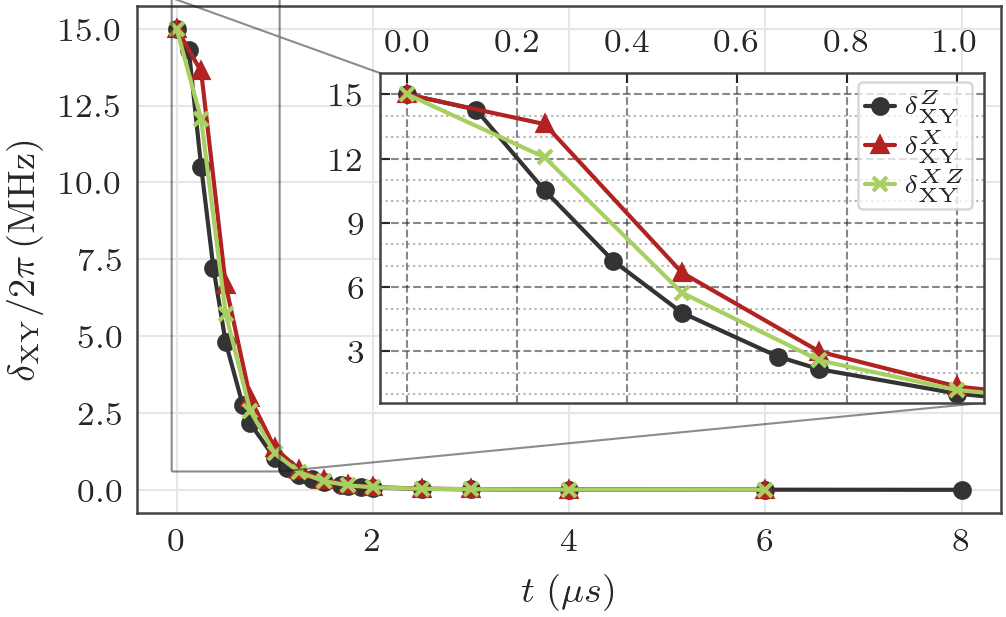

In [5]:
fig = plt.figure(figsize=(SINGLE_WIDTH, SINGLE_WIDTH / golden_ratio))

gs = gridspec.GridSpec(1, 1, figure=fig,
                       )

axs = [fig.add_subplot(gs[0])]

ax = axs[0]

ax.plot(
    XYZ_times, XYZ_deltas, 
    label=r'$\delta_{\mathrm{XY}}^{Z}$', color=COLORS["blackish"], marker ="o", ms=3.5, linestyle="-")
ax.plot(
    XYX_times, XYX_deltas,
    # label=r'$\delta_{\mathrm{XY}}^{X}$', color="xkcd:burgundy", marker ="^", ms=3.5, linestyle="-")
    label=r'$\delta_{\mathrm{XY}}^{X}$', color=COLORS["reddish"], marker ="^", ms=3.5, linestyle="-")
ax.plot(
    XYXZ_times, XYXZ_deltas, 
    # label=r'$\delta_{\mathrm{XY}}^{XZ}$', color="xkcd:olive", marker ="x", ms=3.5, linestyle="-")
    label=r'$\delta_{\mathrm{XY}}^{XZ}$', color=COLORS["green glow"], marker ="x", ms=3.5, linestyle="-")
ax.set_ylabel(r"$\delta_{\mathrm{XY}}/2 \pi \, (\mathrm{MHz})$ ")
ax.set_xlabel(r"$t\;(\mu s)$")

ax_c_inset = inset_axes(
    ax, width='100%', height='100%', 
    bbox_to_anchor=(0.3, 0.25, 0.7, 0.65), bbox_transform=ax.transAxes
    )
ax_c_inset.plot(
    XYZ_times, XYZ_deltas, 
    label=r'$\delta_{\mathrm{XY}}^{Z}$', color=COLORS["blackish"], marker ="o", ms=3.5, linestyle="-")
ax_c_inset.plot(
    XYX_times, XYX_deltas, 
    # label=r'$\delta_{\mathrm{XY}}^{X}$', color="xkcd:burgundy", marker ="^", ms=3.5, linestyle="-")
    label=r'$\delta_{\mathrm{XY}}^{X}$', color=COLORS["reddish"], marker ="^", ms=3.5, linestyle="-")
ax_c_inset.plot(
    XYXZ_times, XYXZ_deltas, 
    # label=r'$\delta_{\mathrm{XY}}^{XZ}$', color="xkcd:olive", marker ="x", ms=3.5, linestyle="-")
    label=r'$\delta_{\mathrm{XY}}^{XZ}$', color=COLORS["green glow"], marker ="x", ms=3.5, linestyle="-")
ax_c_inset.set_xlim(-0.05, 1.05)
ax_c_inset.set_ylim(0.6, 16)
ax_c_inset.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False, left=True)

ax_c_inset.yaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True, nbins=6))
ax_c_inset.yaxis.set_minor_locator(mpl.ticker.MaxNLocator(integer=True, nbins=18))
ax_c_inset.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.55, color="0.15")
ax_c_inset.grid(True, which='minor', linestyle=':', linewidth=0.5, alpha=0.45, color="0.35")
indicator = ax.indicate_inset_zoom(ax_c_inset, edgecolor="k", linewidth=0.5)
for num, line in enumerate(indicator.connectors):
    if num in [1, 2]:  # only show the left and right connectors
        line.set_visible(True)
    else:
        line.set_visible(False)

ax_c_inset.legend(loc="upper right", fontsize=6, frameon=True, bbox_to_anchor=(1.0, 1.01))

fig.savefig("Plots/Fig_A2.pdf")

## Fig_A3: does the choice of train/val split actually matter?

This section is independent of the two figures above: it reads pre-computed summaries
from `Plots_data/App_A_data/*.pickle` (one per dataset) rather than touching `datasets/` at all.
Each pickle holds the mean and standard error of the training and validation goodness
(accuracy) for four splitting scenarios, laid out left to right as the stratified split
used throughout the paper, the same split with samples capped at 500 per time point, a
global random split, and an inverse-frequency weighted loss (the four scenarios defined
in `docs/CONFIGURATION.md`, "Weighted-loss experiment scenario table"). The resulting bar chart is
what backs the appendix's claim that these alternatives change validation accuracy by at
most about two percentage points; that claim is currently stated in prose only in
`data_preparation.tex`, so this figure is generated but not included in the compiled
manuscript.


In [6]:
wl_Ising_path = "Plots_data/App_A_data/Ising.pickle"
wl_XY_Z_path = "Plots_data/App_A_data/XY_Z.pickle"
wl_XY_XZ_path = "Plots_data/App_A_data/XY_XZ.pickle"

with open(wl_Ising_path, "rb") as f:
    wl_Ising_data = pickle.load(f)

with open(wl_XY_Z_path, "rb") as f:
    wl_XY_Z_data = pickle.load(f)

with open(wl_XY_XZ_path, "rb") as f:
    wl_XY_XZ_data = pickle.load(f)

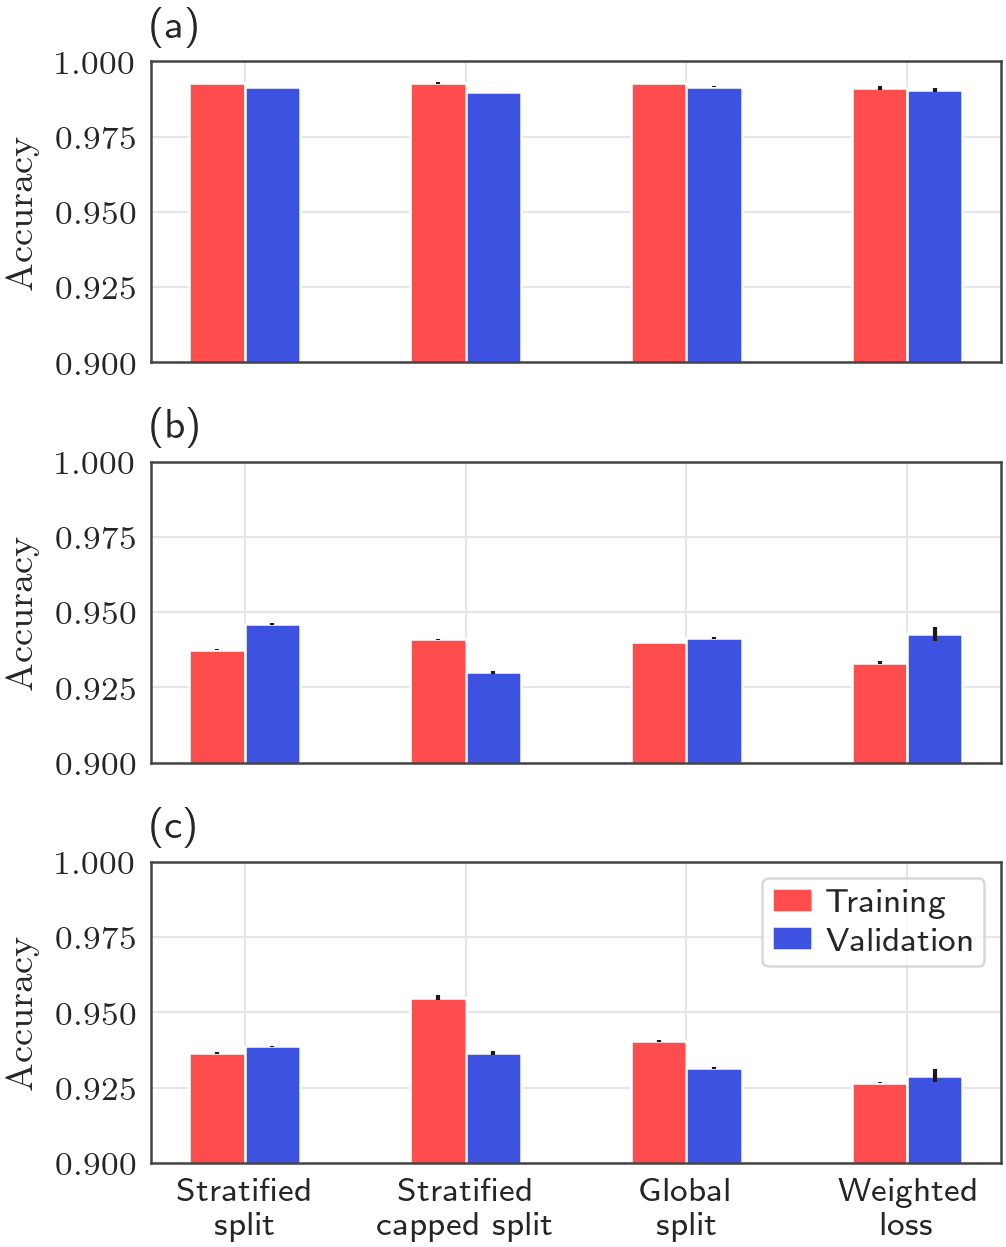

In [7]:
fig = plt.figure(figsize=(SINGLE_WIDTH, 2*SINGLE_WIDTH / golden_ratio))

gs = gridspec.GridSpec(3, 1, figure=fig,
                       )

axs = [fig.add_subplot(gs[i]) for i in range(3)]

bar_alpha = 1.0
goodness_label = r"$\mathrm{Accuracy}$"

# Short scenario names shown on the x-axis (stacked on two lines to fit the column width)
scenario_labels = ["Stratified\nsplit", "Stratified\ncapped split", "Global\nsplit", "Weighted\nloss"]

ax = axs[0]
# Ising

width = 0.25  # width of the bars
x_positions = range(4)
ax.bar(np.array(x_positions) - width/2, wl_Ising_data['train_goodness_means'], width, color=COLORS["red"], alpha=bar_alpha, label=f'Training', yerr=wl_Ising_data['train_goodness_stdes'])
ax.bar(np.array(x_positions) + width/2, wl_Ising_data['val_goodness_means'], width, color=COLORS["blue"], alpha=bar_alpha, label=f'Validation', yerr=wl_Ising_data['val_goodness_stdes'])
ax.set_ylim(0.9, 1.0)  # set y-axis limits for better visibility
ax.set_title("(a)", loc="left")

ax = axs[1]
# XY_Z

width = 0.25  # width of the bars
x_positions = range(4)
ax.bar(np.array(x_positions) - width/2, wl_XY_Z_data['train_goodness_means'], width, color=COLORS["red"], alpha=bar_alpha, label=f'Training', yerr=wl_XY_Z_data['train_goodness_stdes'])
ax.bar(np.array(x_positions) + width/2, wl_XY_Z_data['val_goodness_means'], width, color=COLORS["blue"], alpha=bar_alpha, label=f'Validation', yerr=wl_XY_Z_data['val_goodness_stdes'])
ax.set_ylim(0.9, 1.0)  # set y-axis limits for better visibility
ax.set_title("(b)", loc="left")

ax = axs[2]
# XY_XZ

width = 0.25  # width of the bars
x_positions = range(4)
ax.bar(np.array(x_positions) - width/2, wl_XY_XZ_data['train_goodness_means'], width, color=COLORS["red"], alpha=bar_alpha, label=f'Training', yerr=wl_XY_XZ_data['train_goodness_stdes'])
ax.bar(np.array(x_positions) + width/2, wl_XY_XZ_data['val_goodness_means'], width, color=COLORS["blue"], alpha=bar_alpha, label=f'Validation', yerr=wl_XY_XZ_data['val_goodness_stdes'])
ax.set_ylim(0.9, 1.0)  # set y-axis limits for better visibility
ax.set_title("(c)", loc="left")

for ax in axs:
    ax.set_xticks(x_positions)
    ax.set_xticklabels([])
    ax.set_ylabel(goodness_label)

ax = axs[2]
ax.legend(loc='upper right')

ax = axs[2]
ax.set_xticklabels(scenario_labels)

fig.savefig("Plots/Fig_A3.pdf")